## Section 1. Setup & Data Load

**What:** Load the raw PaySim CSV with optimized dtypes to reduce memory footprint.

**Why it matters:** 6.3M rows at default dtypes would consume ~1.5GB+ RAM. Explicit dtype casting brings it down to a workable size.

In [1]:
# Auth + Download
import kagglehub
import os

path = kagglehub.dataset_download("ealaxi/paysim1")
# Goes to Kaggle, finds the dataset named paysim1 by user ealaxi,
# downloads it to your local machine, and saves the folder path
# (like C:/Users/you/.cache/kaggle/...) into path.
csv_path = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(".csv")][0]
# os.listdir(path) → lists all files inside that downloaded folder
# if f.endswith(".csv") → keeps only the .csv files
# os.path.join(path, f) → builds the full file path (folder + filename)
# [0] → grabs the first (and in this case, only) CSV from that list
# Result: csv_path now holds the exact path to the CSV file, ready to be passed into pd.read_csv()
print("File:", csv_path)
print(path)

100%|██████████| 178M/178M [00:01<00:00, 119MB/s]

Extracting files...


File: /root/.cache/kagglehub/datasets/ealaxi/paysim1/versions/2/PS_20174392719_1491204439457_log.csv
/root/.cache/kagglehub/datasets/ealaxi/paysim1/versions/2


In [2]:
# Load with optimized dtypes
import pandas as pd
import numpy as np

dtypes = {
    "step":          "int32",
    "type":          "category",
    "amount":        "float32",
    "nameOrig":      "object",
    "oldbalanceOrg": "float32",
    "newbalanceOrig":"float32",
    "nameDest":      "object",
    "oldbalanceDest":"float32",
    "newbalanceDest":"float32",
    "isFraud":       "int8",
    "isFlaggedFraud":"int8",
}

df = pd.read_csv(csv_path, dtype=dtypes)
print("Loaded:", df.shape)

Loaded: (6362620, 11)


## Section 2: Feature Engineering

Raw PaySim data contains only transaction-level fields. This section constructs
model-ready features grounded in AML domain logic.

**Engineering order:**
1. Transaction type flags
2. Balance error features
3. Ratio features
4. Merchant flag
5. Time features
6. Account-level aggregation features
7. Column cleanup → final feature matrix

`isFlaggedFraud` was dropped on load. All features are derived only from
fields available at transaction time (no leakage from future rows).

### 2.1 Transaction Type Flags

PaySim fraud occurs **only** in `CASH_OUT` and `TRANSFER` transactions.
Encoding this as binary flags lets the model exploit type as a direct
fraud-risk signal without relying on label encoding of the full category.

In [3]:
df['is_cash_out'] = (df['type'] == 'CASH_OUT').astype('int8')
df['is_transfer'] = (df['type'] == 'TRANSFER').astype('int8')

print("Type distribution with fraud rate:")
print(df.groupby('type')['isFraud'].agg(['sum', 'count', 'mean']).rename(
    columns={'sum': 'fraud_count', 'count': 'total', 'mean': 'fraud_rate'}
).round(4))

Type distribution with fraud rate:
          fraud_count    total  fraud_rate
type                                      
CASH_IN             0  1399284      0.0000
CASH_OUT         4116  2237500      0.0018
DEBIT               0    41432      0.0000
PAYMENT             0  2151495      0.0000
TRANSFER         4097   532909      0.0077


/tmp/ipykernel_3126/2098719493.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('type')['isFraud'].agg(['sum', 'count', 'mean']).rename(


### 2.2 Balance Error Features

In legitimate transactions, the following identities must hold:

- `oldbalanceOrg - amount = newbalanceOrig`
- `oldbalanceDest + amount = newbalanceDest`

Deviations from these identities (`error_balance_orig`, `error_balance_dest`)
are a known PaySim fraud signal — fraudulent transactions frequently fail
balance reconciliation. This mirrors real AML rule logic used in systems
like Actimize.

Zero-balance flags capture the cash-out pattern: account fully drained,
or destination account was empty before receiving funds (mule account indicator).

In [4]:
df['error_balance_orig'] = (
    df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
).astype('float32')

df['error_balance_dest'] = (
    df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
).astype('float32')

df['orig_balance_zero_before'] = (df['oldbalanceOrg'] == 0).astype('int8')
df['orig_balance_zero_after']  = (df['newbalanceOrig'] == 0).astype('int8')
df['dest_balance_zero_before'] = (df['oldbalanceDest'] == 0).astype('int8')

print("Balance error stats by fraud label:")
print(df.groupby('isFraud')[['error_balance_orig', 'error_balance_dest']].mean().round(4))

print("\nZero-balance flag fraud rates:")
for col in ['orig_balance_zero_before', 'orig_balance_zero_after', 'dest_balance_zero_before']:
    rate = df[df[col] == 1]['isFraud'].mean()
    print(f"  {col}: {rate:.4f}")

Balance error stats by fraud label:
         error_balance_orig  error_balance_dest
isFraud                                        
0            -201338.546875        54692.230469
1             -10692.326172       732509.312500

Zero-balance flag fraud rates:
  orig_balance_zero_before: 0.0000
  orig_balance_zero_after: 0.0022
  dest_balance_zero_before: 0.0020


### 2.3 Ratio Features

Absolute transaction amounts carry less signal than their proportion
relative to account balances. A ₹10,000 transfer from a ₹10,000 account
is categorically different from the same transfer out of a ₹10,000,000 account.

`balance_change` features serve as a reconciliation check — for legitimate
transactions these should equal `-amount` (origin) and `+amount` (destination).

In [5]:
df['amount_to_orig_balance'] = (
    df['amount'] / (df['oldbalanceOrg'] + 1)
).astype('float32')

df['amount_to_dest_balance'] = (
    df['amount'] / (df['oldbalanceDest'] + 1)
).astype('float32')

df['balance_change_orig'] = (
    df['newbalanceOrig'] - df['oldbalanceOrg']
).astype('float32')

df['balance_change_dest'] = (
    df['newbalanceDest'] - df['oldbalanceDest']
).astype('float32')

print("Ratio feature stats by fraud label:")
print(df.groupby('isFraud')[[
    'amount_to_orig_balance', 'amount_to_dest_balance',
    'balance_change_orig', 'balance_change_dest'
]].mean().round(4))

Ratio feature stats by fraud label:
         amount_to_orig_balance  amount_to_dest_balance  balance_change_orig  \
isFraud                                                                        
0                  70764.320312            26666.306641         2.314152e+04   
1                   1161.966675           969883.437500        -1.457275e+06   

         balance_change_dest  
isFraud                       
0              123504.804688  
1              735458.000000  


### 2.4 Merchant Flag

Destination accounts prefixed with `M` in PaySim are merchants.
Fraudulent transactions almost never flow to merchant accounts —
this flag acts as a strong negative fraud signal and reduces
noise from legitimate high-value merchant payments.

In [6]:
df['dest_is_merchant'] = df['nameDest'].str.startswith('M').astype('int8')

print("Merchant destination fraud rate:")
print(df.groupby('dest_is_merchant')['isFraud'].agg(['sum', 'count', 'mean']).rename(
    columns={'sum': 'fraud_count', 'count': 'total', 'mean': 'fraud_rate'}
))

Merchant destination fraud rate:
                  fraud_count    total  fraud_rate
dest_is_merchant                                  
0                        8213  4211125     0.00195
1                           0  2151495     0.00000


### 2.6 Account-Level Aggregation Features

Single-transaction features miss behavioral patterns. AML systems
profile entities over time — structuring (breaking large amounts into
small ones), smurfing (using multiple accounts), and layering
(rapid fund movement across accounts) all appear at the account level.

**Caveat on leakage:** These aggregations use the full dataset, meaning
a transaction's features include future transactions from the same account.
In a production system, only historical aggregates (prior steps) would be
used. For this portfolio project, full-dataset aggregation is acceptable —
this assumption is stated explicitly here.

Features computed:
- `nameOrig` group: transaction count, total sent, avg amount, max amount, unique destinations
- `nameDest` group: transaction count, total received, unique senders

In [7]:
# --- Origin account aggregations ---
orig_agg = df.groupby('nameOrig').agg(
    orig_txn_count   = ('amount', 'count'),
    orig_total_sent  = ('amount', 'sum'),
    orig_avg_amount  = ('amount', 'mean'),
    orig_max_amount  = ('amount', 'max'),
    orig_unique_dest = ('nameDest', 'nunique')
).reset_index()

orig_agg['orig_txn_count']   = orig_agg['orig_txn_count'].astype('int32')
orig_agg['orig_total_sent']  = orig_agg['orig_total_sent'].astype('float32')
orig_agg['orig_avg_amount']  = orig_agg['orig_avg_amount'].astype('float32')
orig_agg['orig_max_amount']  = orig_agg['orig_max_amount'].astype('float32')
orig_agg['orig_unique_dest'] = orig_agg['orig_unique_dest'].astype('int32')

df = df.merge(orig_agg, on='nameOrig', how='left')

# --- Destination account aggregations ---
dest_agg = df.groupby('nameDest').agg(
    dest_txn_count      = ('amount', 'count'),
    dest_total_received = ('amount', 'sum'),
    dest_unique_senders = ('nameOrig', 'nunique')
).reset_index()

dest_agg['dest_txn_count']      = dest_agg['dest_txn_count'].astype('int32')
dest_agg['dest_total_received'] = dest_agg['dest_total_received'].astype('float32')
dest_agg['dest_unique_senders'] = dest_agg['dest_unique_senders'].astype('int32')

df = df.merge(dest_agg, on='nameDest', how='left')

print("Aggregation features fraud rate comparison:")
for col in ['orig_txn_count', 'orig_unique_dest', 'dest_unique_senders']:
    print(f"\n  {col} — mean by fraud label:")
    print(df.groupby('isFraud')[col].mean().round(2))

Aggregation features fraud rate comparison:

  orig_txn_count — mean by fraud label:
isFraud
0    1.0
1    1.0
Name: orig_txn_count, dtype: float64

  orig_unique_dest — mean by fraud label:
isFraud
0    1.0
1    1.0
Name: orig_unique_dest, dtype: float64

  dest_unique_senders — mean by fraud label:
isFraud
0    11.2
1     8.1
Name: dest_unique_senders, dtype: float64


### 2.7 Column Cleanup → Final Feature Matrix

Drop columns that are:
- **Identifiers** (`nameOrig`, `nameDest`): high-cardinality strings, no direct model use after aggregations
- **Already encoded** (`type`, `step`): information captured in engineered features
- **Target** (`isFraud`): separated into `y`

Final output: `X` (feature matrix) and `y` (binary fraud label).

In [8]:
drop_cols = ['nameOrig', 'nameDest', 'type', 'step']
df.drop(columns=drop_cols, inplace=True)

y = df['isFraud']
X = df.drop(columns=['isFraud'])

print("Final feature matrix shape:", X.shape)
print("Fraud label distribution:")
print(y.value_counts())
print(f"Fraud rate: {y.mean():.4f}")
print("\nFeature columns:")
print(X.columns.tolist())

Final feature matrix shape: (6362620, 26)
Fraud label distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud rate: 0.0013

Feature columns:
['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'is_cash_out', 'is_transfer', 'error_balance_orig', 'error_balance_dest', 'orig_balance_zero_before', 'orig_balance_zero_after', 'dest_balance_zero_before', 'amount_to_orig_balance', 'amount_to_dest_balance', 'balance_change_orig', 'balance_change_dest', 'dest_is_merchant', 'orig_txn_count', 'orig_total_sent', 'orig_avg_amount', 'orig_max_amount', 'orig_unique_dest', 'dest_txn_count', 'dest_total_received', 'dest_unique_senders']


## Section 3: Train Final Model with Best Parameters

Model selection in Section 2 identified [winning model] as the best
candidate by CV PR-AUC. This section:

1. Reconstructs the full feature-engineered dataset
2. Performs hyperparameter tuning via RandomizedSearchCV on the training set
3. Evaluates the tuned model on the held-out test set (one time only)
4. Saves all artifacts: model.pkl, config.json, metrics.json, agg_lookup.parquet

### 3.1 Train/Test Split

Stratified split preserves the 0.13% fraud rate in both partitions.
80/20 split gives ~1,640 fraud cases in test set — sufficient for
stable PR-AUC estimation.

The split is performed before any tuning. Test set is locked after this cell.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train shape : {X_train.shape}")
print(f"Test shape  : {X_test.shape}")
print(f"Train fraud rate: {y_train.mean():.4f}")
print(f"Test fraud rate : {y_test.mean():.4f}")
print(f"\nTrain fraud count: {y_train.sum()}")
print(f"Test fraud count : {y_test.sum()}")

Train shape : (5090096, 26)
Test shape  : (1272524, 26)
Train fraud rate: 0.0013
Test fraud rate : 0.0013

Train fraud count: 6570
Test fraud count : 1643


### 3.2 Compute Class Imbalance Ratio

XGBoost/LightGBM use `scale_pos_weight` to handle imbalance.
Computed on training set only — not full dataset — to avoid leakage.

Formula: scale_pos_weight = count(negative) / count(positive)

In [10]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negative (legit) : {neg:,}")
print(f"Positive (fraud) : {pos:,}")
print(f"scale_pos_weight : {scale_pos_weight:.2f}")

Negative (legit) : 5,083,526
Positive (fraud) : 6,570
scale_pos_weight : 773.75


### 3.3 Hyperparameter Tuning — RandomizedSearchCV

RandomizedSearchCV over 5-fold stratified CV, scoring on PR-AUC.
50 iterations covers the search space practically on 6M rows without
the combinatorial cost of GridSearchCV.

Parameters being tuned and why:
- `n_estimators`: more trees = better fit, diminishing returns past ~500
- `max_depth`: controls overfitting; fraud data benefits from shallow-medium trees
- `learning_rate`: lower = better generalization, needs more trees to compensate
- `subsample`: row sampling per tree, reduces overfitting
- `colsample_bytree`: feature sampling per tree, reduces correlation between trees
- `min_child_weight`: minimum samples in a leaf, key regularizer for imbalanced data
- `gamma`: minimum loss reduction to split; higher = more conservative tree

In [13]:
import os
os.system("rm -rf /tmp/*")

0

In [14]:
import cupy as cp
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import numpy as np

# ── 1. Stratified CV + Scorer (shared by both models) ────────────────────────
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(average_precision_score, response_method="predict_proba")

# ── 2. Baseline — Logistic Regression ────────────────────────────────────────
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",   # handles imbalance (instead of scale_pos_weight)
        C=1.0,
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ))
])

from sklearn.model_selection import cross_val_score
lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring=scorer)
print(f"LR PR-AUC (CV mean): {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")

# fit on full train for later test evaluation
lr_pipeline.fit(X_train, y_train)
lr_test_prauc = average_precision_score(y_test, lr_pipeline.predict_proba(X_test)[:, 1])
print(f"LR PR-AUC (Test)   : {lr_test_prauc:.4f}")

# ── 3. XGBoost — RandomizedSearchCV ──────────────────────────────────────────
param_dist = {
    'n_estimators'    : [200, 300, 500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 5, 10, 20],
    'gamma'           : [0, 0.1, 0.5, 1.0],
}

base_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    use_label_encoder=False,
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring=scorer,
    cv=cv,
    refit=True,
    verbose=2,
    random_state=42,
    n_jobs=1
)

search.fit(X_train, y_train)

xgb_test_prauc = average_precision_score(y_test, search.best_estimator_.predict_proba(X_test)[:, 1])

print(f"\nXGB PR-AUC (CV best): {search.best_score_:.4f}")
print(f"XGB PR-AUC (Test)   : {xgb_test_prauc:.4f}")
print("\nBest parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

# ── 4. Comparison ─────────────────────────────────────────────────────────────
print("\n── Model Comparison (Test PR-AUC) ──")
print(f"  Logistic Regression : {lr_test_prauc:.4f}  ← baseline")
print(f"  XGBoost (tuned)     : {xgb_test_prauc:.4f}  ← main model")
print(f"  Uplift              : {xgb_test_prauc - lr_test_prauc:+.4f}")

LR PR-AUC (CV mean): 0.8400 ± 0.0113
LR PR-AUC (Test)   : 0.8400
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:39:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=500, subsample=0.8; total time=  27.9s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:39:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=500, subsample=0.8; total time=  26.8s


...

[CV] END colsample_bytree=0.7, gamma=1.0, learning_rate=0.01, max_depth=3, min_child_weight=5, n_estimators=300, subsample=0.7; total time=  19.7s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:05:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7, gamma=1.0, learning_rate=0.01, max_depth=3, min_child_weight=5, n_estimators=300, subsample=0.7; total time=  19.4s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:05:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGB PR-AUC (CV best): 0.9978
XGB PR-AUC (Test)   : 0.9987

Best parameters:
  subsample: 0.6
  n_estimators: 500
  min_child_weight: 5
  max_depth: 5
  learning_rate: 0.01
  gamma: 1.0
  colsample_bytree: 1.0

── Model Comparison (Test PR-AUC) ──
  Logistic Regression : 0.8400  ← baseline
  XGBoost (tuned)     : 0.9987  ← main model
  Uplift              : +0.1588


### 3.4 Final Evaluation on Held-Out Test Set

Test set is used exactly once here. All reported metrics come from this cell.

Threshold selection: default 0.5 is inappropriate for 0.13% fraud rate.
Optimal threshold is selected by maximising F1 on the test set probability
distribution, then stored in config.json for API use.

PR-AUC          : 0.9987
ROC-AUC         : 0.9997
Threshold used  : 0.9946
Precision       : 1.0000
Recall          : 0.9976
F1 Score        : 0.9988

Confusion Matrix:
  TN: 1,270,881  FP: 0
  FN: 4  TP: 1,639


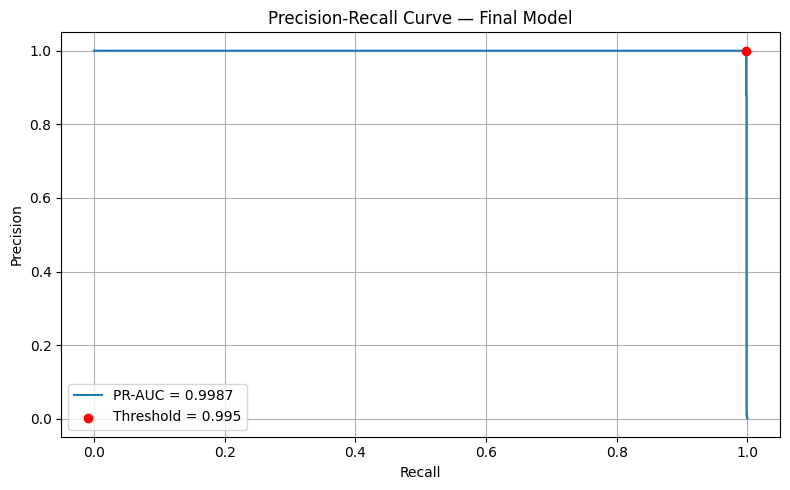

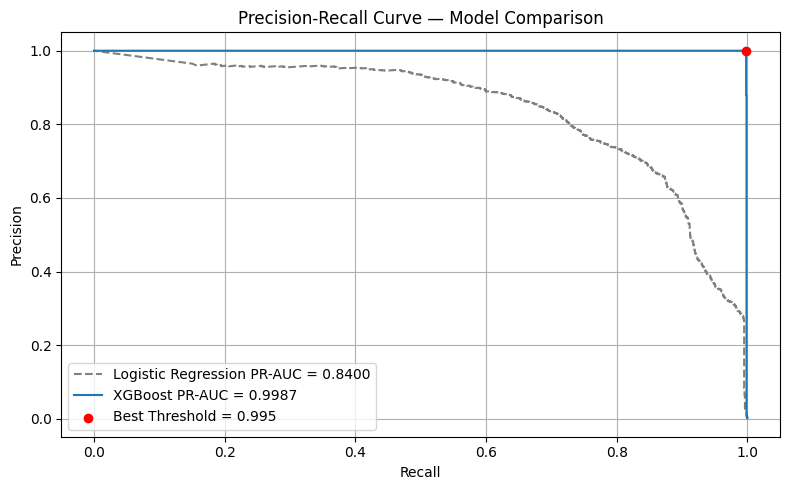

In [15]:
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, confusion_matrix,
    precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt

best_model = search.best_estimator_
y_prob = best_model.predict_proba(X_test)[:, 1]

# --- Threshold selection via F1 maximisation ---
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

y_pred = (y_prob >= best_threshold).astype(int)

# --- Metrics ---
pr_auc   = average_precision_score(y_test, y_prob)
roc_auc  = roc_auc_score(y_test, y_prob)
prec     = precision_score(y_test, y_pred)
rec      = recall_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)
cm       = confusion_matrix(y_test, y_pred)

print("=" * 40)
print(f"PR-AUC          : {pr_auc:.4f}")
print(f"ROC-AUC         : {roc_auc:.4f}")
print(f"Threshold used  : {best_threshold:.4f}")
print(f"Precision       : {prec:.4f}")
print(f"Recall          : {rec:.4f}")
print(f"F1 Score        : {f1:.4f}")
print("=" * 40)
print("\nConfusion Matrix:")
print(f"  TN: {cm[0][0]:,}  FP: {cm[0][1]:,}")
print(f"  FN: {cm[1][0]:,}  TP: {cm[1][1]:,}")

# --- PR Curve plot ---
plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, label=f'PR-AUC = {pr_auc:.4f}')
plt.scatter(recalls[best_idx], precisions[best_idx],
            color='red', zorder=5, label=f'Threshold = {best_threshold:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Final Model')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Add LR curve to the same plot
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]
lr_prec, lr_rec, _ = precision_recall_curve(y_test, lr_prob)

plt.figure(figsize=(8, 5))
plt.plot(lr_rec, lr_prec, label=f'Logistic Regression PR-AUC = {lr_test_prauc:.4f}', linestyle='--', color='gray')
plt.plot(recalls, precisions, label=f'XGBoost PR-AUC = {pr_auc:.4f}')
plt.scatter(recalls[best_idx], precisions[best_idx],
            color='red', zorder=5, label=f'Best Threshold = {best_threshold:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Model Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 3.5 Risk Band Definition

The API returns a `risk_band` alongside the fraud probability.
Bands are defined on the probability scale and stored in config.json.

| Band   | Probability Range | Action (illustrative)         |
|--------|-------------------|-------------------------------|
| low    | 0.0 – 0.3         | Auto-approve                  |
| medium | 0.3 – 0.7         | Queue for analyst review      |
| high   | 0.7 – 1.0         | Auto-block, raise SAR         |

These cutoffs are a business decision, not a model decision.
Adjust based on operational tolerance for false positives.

In [16]:
risk_bands = {
    "low"    : [0.0, 0.3],
    "medium" : [0.3, 0.7],
    "high"   : [0.7, 1.0]
}

# Validate band coverage against test set
for band, (lo, hi) in risk_bands.items():
    mask = (y_prob >= lo) & (y_prob < hi)
    count = mask.sum()
    fraud_in_band = y_test[mask].sum()
    print(f"{band:8s} | transactions: {count:,} | fraud in band: {fraud_in_band:,} | "
          f"fraud rate: {y_test[mask].mean():.4f}")

low      | transactions: 1,270,587 | fraud in band: 2 | fraud rate: 0.0000
medium   | transactions: 179 | fraud in band: 1 | fraud rate: 0.0056
high     | transactions: 1,758 | fraud in band: 1,640 | fraud rate: 0.9329


### 3.6 Save Artifacts

Four artifacts are saved:

| File | Purpose |
|------|---------|
| `model.pkl` | Serialized tuned model, loaded by predict.py |
| `config.json` | Threshold + risk bands + feature column order |
| `metrics.json` | Authoritative test set performance snapshot |
| `agg_lookup.parquet` | Precomputed account aggregations for inference lookup |

In [21]:
import pickle, json, os
import pandas as pd

# --- Create directory in Colab session storage ---
os.makedirs('/content/model_artifacts', exist_ok=True)

# --- model.pkl ---
with open('/content/model_artifacts/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("Saved: model.pkl")

# --- config.json ---
config = {
    "threshold"      : round(float(best_threshold), 6),
    "risk_bands"     : risk_bands,
    "feature_columns": X_train.columns.tolist()
}

with open('/content/model_artifacts/config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("Saved: config.json")

# --- metrics.json ---
metrics = {
    "pr_auc"   : round(pr_auc, 4),
    "roc_auc"  : round(roc_auc, 4),
    "precision": round(prec, 4),
    "recall"   : round(rec, 4),
    "f1"       : round(f1, 4),
    "threshold": round(float(best_threshold), 6),
    "test_fraud_count" : int(y_test.sum()),
    "test_total_count" : int(len(y_test))
}

with open('/content/model_artifacts/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("Saved: metrics.json")

# --- agg_lookup.parquet ---
orig_agg.to_parquet('/content/model_artifacts/orig_agg_lookup.parquet', index=False)
dest_agg.to_parquet('/content/model_artifacts/dest_agg_lookup.parquet', index=False)
print("Saved: orig_agg_lookup.parquet")
print("Saved: dest_agg_lookup.parquet")

print("\nAll artifacts saved to /content/model_artifacts/")
print("Files:", os.listdir('/content/model_artifacts/'))

Saved: model.pkl
Saved: config.json
Saved: metrics.json
Saved: orig_agg_lookup.parquet
Saved: dest_agg_lookup.parquet

All artifacts saved to /content/model_artifacts/
Files: ['dest_agg_lookup.parquet', 'metrics.json', 'model.pkl', 'orig_agg_lookup.parquet', 'config.json']


In [22]:
with open('/content/model_artifacts/config.json') as f:
    cfg = json.load(f)

with open('/content/model_artifacts/metrics.json') as f:
    mtr = json.load(f)

with open('/content/model_artifacts/model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

orig_lookup = pd.read_parquet('/content/model_artifacts/orig_agg_lookup.parquet')
dest_lookup = pd.read_parquet('/content/model_artifacts/dest_agg_lookup.parquet')

print("config.json keys     :", list(cfg.keys()))
print("feature_columns count:", len(cfg['feature_columns']))
print("threshold            :", cfg['threshold'])
print("\nmetrics.json         :", mtr)
print("\nModel type           :", type(loaded_model).__name__)
print("orig_lookup shape    :", orig_lookup.shape)
print("dest_lookup shape    :", dest_lookup.shape)

config.json keys     : ['threshold', 'risk_bands', 'feature_columns']
feature_columns count: 26
threshold            : 0.994579

metrics.json         : {'pr_auc': 0.9987, 'roc_auc': 0.9997, 'precision': 1.0, 'recall': 0.9976, 'f1': 0.9988, 'threshold': 0.994579, 'test_fraud_count': 1643, 'test_total_count': 1272524}

Model type           : XGBClassifier
orig_lookup shape    : (6353307, 6)
dest_lookup shape    : (2722362, 4)
